In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import datetime as dt

In [37]:
df = pd.read_csv('spx_w/eoy_chains.csv')
df.sort_values(['quote', 'strike'], inplace=True)

In [3]:
len(df)

344720

In [38]:
df.dropna(subset=['Bid', 'Ask', 'Implied Volatility'], how='all', inplace=True)

In [43]:
df.isna().sum()

Ask              13
Bid            1883
quote             0
exp               0
T                 0
option_type       0
strike            0
underlying        0
DF                0
div               0
fwd               0
Mid               2
r                 0
forward           0
spot              0
IV             1053
dtype: int64

In [ ]:
# Convert all columns except quote, exp, and option_type to numeric
for col in df.columns:
    if col not in ['quote', 'exp', 'option_type']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    elif col == 'option_type':
        df[col] = df[col].astype('category')
    else:
        df[col] = pd.to_datetime(df[col], format='%Y-%m-%d')

# calculate df["Mid"] as the average of Bid and Ask but if either bid or ask is NaN, use the other value
df["Mid"] = df[["Bid", "Ask"]].mean(axis=1)
df["Mid"].fillna(df[["Bid", "Ask"]].max(axis=1), inplace=True)
# Transformations
df["Implied Volatility"] /= 100
df["T"] /= 365
df["r"] = -np.log(df["DF"]) / df["T"]
# Strip out discounted dividends from underlying price
df["spot"] = df["underlying"]
df["underlying"] = df["spot"] - df["div"] * df["DF"]
df["forward"] = df["underlying"] * np.exp(df["r"] * df["T"])

In [41]:
from scipy.stats import norm

def bsm_call_price(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bsm_put_price(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def implied_volatility(S, K, T, r, market_price, option_type, tol=1e-5, max_iterations=100):
    """Calculate implied volatility using the Bisection method."""
    lower_bound = 1e-2
    upper_bound = 5
    for _ in np.arange(max_iterations):
        sigma = (lower_bound + upper_bound) / 2
        if option_type == 'c':
            price = bsm_call_price(S, K, T, r, sigma)
        else:
            price = bsm_put_price(S, K, T, r, sigma)
        if np.abs(price - market_price) < tol:
            return sigma
        if price < market_price:
            lower_bound = sigma
        else:
            upper_bound = sigma
    return np.nan  # Return NaN if no solution found within max_iterations

# Calculate implied volatility only for rows where Implied Volatility is NaN and Mid is not NaN
df['IV'] = np.where(
    df['Implied Volatility'].isna() & df['Mid'].notna(),
    np.nan,
    df['Implied Volatility']
)
df['IV'] = df.apply(
    lambda row: implied_volatility(
        row['underlying'],
        row['strike'],
        row['T'],
        row['r'],
        row['Mid'],
        row['option_type']
    ) if pd.isna(row['IV']) else row['IV'],
    axis=1
)
df.drop(columns=['Implied Volatility'], inplace=True)

In [44]:
df[df["IV"].isna()]

,Ask,Bid,quote,exp,T,option_type,strike,underlying,DF,div,fwd,Mid,r,forward,spot,IV
234643,3828.0,3805.6,2022-01-14,2022-12-30,0.958904,c,800.0,4610.123249,0.991561,53.175484,4648.905278,3816.80,0.008838,4702.533313,4662.85,NaN
194312,3656.9,3632.9,2022-02-07,2022-12-30,0.893151,c,800.0,4440.182916,0.990813,44.092167,4480.945136,3644.90,0.010334,4525.446143,4483.87,NaN
194635,3460.0,3436.0,2022-02-07,2022-12-30,0.893151,c,1000.0,4440.182916,0.990813,44.092167,4480.945136,3448.00,0.010334,4525.446143,4483.87,NaN
194320,3550.1,3527.1,2022-02-17,2022-12-30,0.865753,c,800.0,4330.316743,0.989576,50.469360,4375.400660,3538.60,0.012104,4426.401664,4380.26,NaN
179642,3369.1,3345.1,2022-03-07,2022-12-30,0.816438,c,800.0,4149.723386,0.990223,51.873761,4190.181789,3357.10,0.012034,4242.567704,4201.09,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118966,2634.9,2611.4,2024-06-10,2024-12-31,0.558904,c,2800.0,5344.877851,0.971691,16.375734,5500.118637,2623.15,0.051382,5516.971462,5360.79,NaN
118947,2586.7,2563.2,2024-06-10,2024-12-31,0.558904,c,2850.0,5344.877851,0.971691,16.375734,5500.118637,2574.95,0.051382,5516.971462,5360.79,NaN
118928,2537.3,2515.4,2024-06-10,2024-12-31,0.558904,c,2900.0,5344.877851,0.971691,16.375734,5500.118637,2526.35,0.051382,5516.971462,5360.79,NaN
118909,2489.1,2467.1,2024-06-10,2024-12-31,0.558904,c,2950.0,5344.877851,0.971691,16.375734,5500.118637,2478.10,0.051382,5516.971462,5360.79,NaN


In [47]:
from scipy.interpolate import LSQUnivariateSpline

for opt_type in df['option_type'].unique():
    for opt_date in df['quote'].unique():
        temp = df[(df['quote']==opt_date) & (df['option_type']==opt_type)].copy()
        nonan_temp = temp.dropna(subset=['IV'])
        knots = 10
        if nonan_temp.empty: continue
        if len(nonan_temp) < knots + 2: knots = len(nonan_temp) - 2
        knots = np.linspace(nonan_temp["strike"].min(), nonan_temp["strike"].max(), knots+2)[1:-1]
        lsqs = LSQUnivariateSpline(nonan_temp["strike"], nonan_temp["IV"], knots)
        df.loc[(df['quote']==opt_date) & (df['option_type']==opt_type), 'LSQ_Vol'] = lsqs(temp['strike'])

In [ ]:
# Calculate BSM price for options chain using the LSQ volatility
df["BSM"] = np.where(
    df["option_type"] == "c",
    bsm_call_price(df["underlying"], df["strike"], df["T"], df["r"], df["LSQ_Vol"]),
    bsm_put_price(df["underlying"], df["strike"], df["T"], df["r"], df["LSQ_Vol"])
)
# Control variate with 0.2 lambda
df["BSM"] = df["BSM"] + 0.2 * (df["Mid"] - df["BSM"])

In [59]:
df

,Ask,Bid,quote,exp,T,option_type,strike,underlying,DF,div,fwd,Mid,r,forward,spot,IV,LSQ_Vol,BSM
234614,4.00,0.35,2022-01-03,2022-12-30,0.989041,p,800.0,4734.274857,0.992184,62.775806,4771.075536,2.175,0.007934,4834.345871,4796.56,0.703800,0.703219,2.182612
234634,3954.20,3931.00,2022-01-03,2022-12-30,0.989041,c,800.0,4734.274857,0.992184,62.775806,4771.075536,3942.600,0.007934,4834.345871,4796.56,0.699100,0.692961,3942.472403
234594,5.40,1.75,2022-01-03,2022-12-30,0.989041,p,1000.0,4734.274857,0.992184,62.775806,4771.075536,3.575,0.007934,4834.345871,4796.56,0.652800,0.655110,3.669680
237078,3756.60,3734.10,2022-01-03,2022-12-30,0.989041,c,1000.0,4734.274857,0.992184,62.775806,4771.075536,3745.350,0.007934,4834.345871,4796.56,0.645241,0.670948,3746.320025
234574,7.20,3.50,2022-01-03,2022-12-30,0.989041,p,1200.0,4734.274857,0.992184,62.775806,4771.075536,5.350,0.007934,4834.345871,4796.56,0.608900,0.608564,5.359817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154835,0.15,0.05,2024-11-19,2024-12-31,0.115068,c,7500.0,5912.883828,0.993662,4.122301,5950.574522,0.100,0.055259,5954.723118,5916.98,0.222120,0.215688,0.102510
148593,1648.40,1631.90,2024-11-19,2024-12-31,0.115068,p,7600.0,5912.883828,0.993662,4.122301,5950.574522,1640.150,0.055259,5954.723118,5916.98,0.304568,0.276746,1639.905547
154827,0.15,0.05,2024-11-19,2024-12-31,0.115068,c,7600.0,5912.883828,0.993662,4.122301,5950.574522,0.100,0.055259,5954.723118,5916.98,0.228857,0.223672,0.088540
148580,1847.20,1830.50,2024-11-19,2024-12-31,0.115068,p,7800.0,5912.883828,0.993662,4.122301,5950.574522,1838.850,0.055259,5954.723118,5916.98,0.263233,0.272470,1838.157476


In [60]:
chain = df[df["option_type"] == "c"]

In [61]:
chain[chain["quote"] == "2022-01-03"]

,Ask,Bid,quote,exp,T,option_type,strike,underlying,DF,div,fwd,Mid,r,forward,spot,IV,LSQ_Vol,BSM
234634,3954.2,3931.00,2022-01-03,2022-12-30,0.989041,c,800.0,4734.274857,0.992184,62.775806,4771.075536,3942.600,0.007934,4834.345871,4796.56,0.699100,0.692961,3942.472403
237078,3756.6,3734.10,2022-01-03,2022-12-30,0.989041,c,1000.0,4734.274857,0.992184,62.775806,4771.075536,3745.350,0.007934,4834.345871,4796.56,0.645241,0.670948,3746.320025
237058,3559.4,3537.90,2022-01-03,2022-12-30,0.989041,c,1200.0,4734.274857,0.992184,62.775806,4771.075536,3548.650,0.007934,4834.345871,4796.56,0.602944,0.582267,3547.688779
237038,3362.9,3341.80,2022-01-03,2022-12-30,0.989041,c,1400.0,4734.274857,0.992184,62.775806,4771.075536,3352.350,0.007934,4834.345871,4796.56,0.564541,0.495292,3348.684625
237018,3264.8,3243.90,2022-01-03,2022-12-30,0.989041,c,1500.0,4734.274857,0.992184,62.775806,4771.075536,3254.350,0.007934,4834.345871,4796.56,0.395400,0.467701,3249.678470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236838,8.7,4.70,2022-01-03,2022-12-30,0.989041,c,6300.0,4734.274857,0.992184,62.775806,4771.075536,6.700,0.007934,4834.345871,4796.56,0.146400,0.146301,8.148807
236818,7.3,3.40,2022-01-03,2022-12-30,0.989041,c,6400.0,4734.274857,0.992184,62.775806,4771.075536,5.350,0.007934,4834.345871,4796.56,0.148100,0.146256,6.211153
236798,6.2,2.40,2022-01-03,2022-12-30,0.989041,c,6500.0,4734.274857,0.992184,62.775806,4771.075536,4.300,0.007934,4834.345871,4796.56,0.148100,0.147623,4.984457
236778,5.5,1.65,2022-01-03,2022-12-30,0.989041,c,6600.0,4734.274857,0.992184,62.775806,4771.075536,3.575,0.007934,4834.345871,4796.56,0.151800,0.151605,4.469763


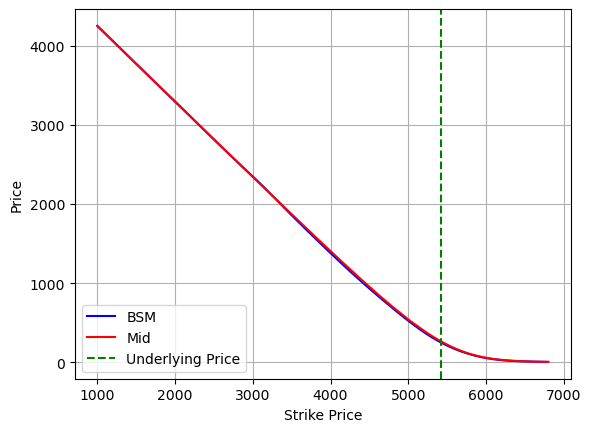

In [75]:
sample_date = np.random.choice(chain["quote"].unique(), 1)[0]
plt.plot(chain[chain["quote"] == sample_date]["strike"], chain[chain["quote"] == sample_date]["BSM"], label="BSM", color="blue")
plt.plot(chain[chain["quote"] == sample_date]["strike"], chain[chain["quote"] == sample_date]["Mid"], label="Mid", color="red")
plt.axvline(x=chain[chain["quote"] == sample_date]["fwd"].values[0], color="green", linestyle="--", label="Underlying Price")
# plt.title(f"Call Option Prices on {sample_date.astype('datetime64[D]')}")
plt.xlabel("Strike Price")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

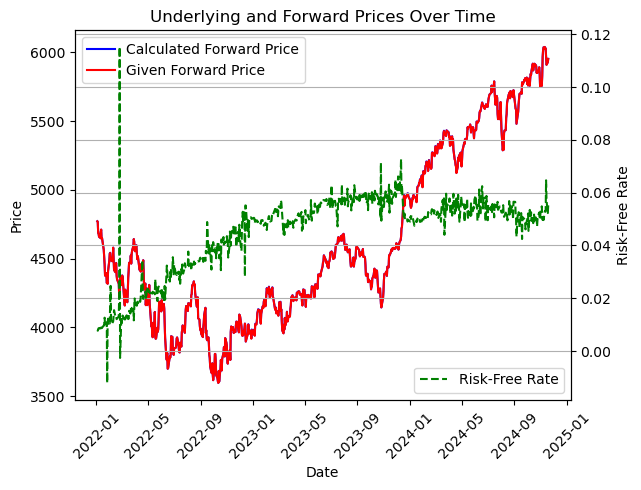

In [76]:
# Plot forwards across all dates
plt.plot(df["quote"], df["forward"], label="Calculated Forward Price", color="blue")
plt.plot(df["quote"], df["fwd"], label="Given Forward Price", color="red")
# second axis plot risk-free rate
plt.title("Underlying and Forward Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.twinx().plot(df["quote"], df["r"], label="Risk-Free Rate", color="green", linestyle="--")
plt.ylabel("Risk-Free Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [83]:
temp = chain[chain["quote"] == sample_date]

import warnings
warnings.filterwarnings("ignore")

from statsmodels.nonparametric.smoothers_lowess import lowess
temp["Lowess_Vol"] = lowess(temp["IV"], temp["strike"], frac=0.3)[:, 1]

from scipy.interpolate import UnivariateSpline
temp["Cubic_Vol"] = UnivariateSpline(temp["strike"], temp["IV"], k=3, s=0.05)(temp["strike"])

# from scipy.interpolate import PchipInterpolator
# temp["Pchip_Vol"] = PchipInterpolator(temp["strike"], temp["Implied Volatility"])(temp["strike"])

temp["Polyfit_Vol"] = np.poly1d(np.polyfit(temp["strike"], temp["IV"], 3))(temp["strike"])

# Implement SABR model
from pysabr import Hagan2002LognormalSABR, hagan_2002_lognormal_sabr as sabr

# Fit SABR model to implied volatilities
beta = 0.5  # Set beta to 0.5 for lognormal SABR
sabr_lognormal = Hagan2002LognormalSABR(f=temp["fwd"].values[0], t=temp["T"].values[0], beta=beta)
alpha, rho, volvol = sabr_lognormal.fit(temp["strike"], temp["IV"])
temp["SABR_Vol"] = [sabr.lognormal_vol(s, temp["fwd"].values[0], temp["T"].values[0], alpha, beta, rho, volvol) * 100 for s in temp["strike"]]

from scipy.interpolate import LSQUnivariateSpline
knots = np.linspace(temp["strike"].min(), temp["strike"].max(), 12)[1:-1]
temp["LSQ_Vol"] = LSQUnivariateSpline(temp["strike"], temp["IV"], knots)(temp["strike"])

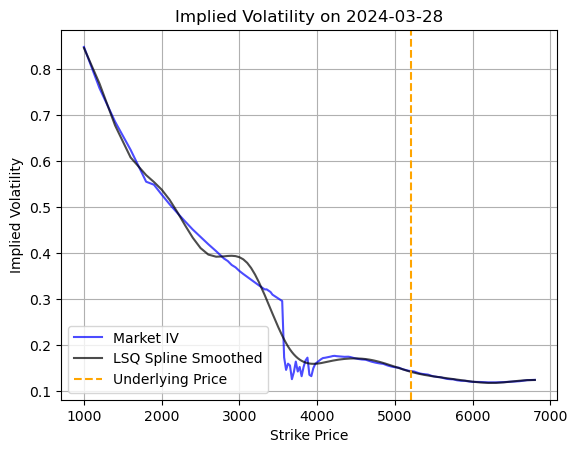

In [85]:
plt.plot(temp["strike"], temp["IV"], label="Market IV", color="blue", alpha=0.7)
# plt.plot(temp["strike"], temp["Lowess_Vol"], label="Lowess Smoothed", color="red", alpha=0.7)
# plt.plot(temp["strike"], temp["Cubic_Vol"], label="Cubic Spline Smoothed", color="green", alpha=0.7)
# plt.plot(temp["strike"], temp["Polyfit_Vol"], label="Polynomial Smoothed", color="purple", alpha=0.7)
# plt.plot(temp["strike"], temp["SABR_Vol"], label="SABR Smoothed", color="orange", alpha=0.7)
plt.plot(temp["strike"], temp["LSQ_Vol"], label="LSQ Spline Smoothed", color="black", alpha=0.7)
plt.axvline(x=temp["underlying"].values[0], color="orange", linestyle="--", label="Underlying Price")
plt.title(f"Implied Volatility on {sample_date.astype('datetime64[D]')}")
plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility")
plt.legend()
plt.grid()
plt.show()

In [36]:
with open("kalshi_data.pkl", "rb") as f:
    kalshi_data = pickle.load(f)

In [37]:
kalshi_data

{2022: {'tickers': ['INXY-22DEC30-B2700',
   'INXY-22DEC30-B2900',
   'INXY-22DEC30-B3100',
   'INXY-22DEC30-B3300',
   'INXY-22DEC30-B3500',
   'INXY-22DEC30-B3700',
   'INXY-22DEC30-B3900',
   'INXY-22DEC30-B4100',
   'INXY-22DEC30-B4300',
   'INXY-22DEC30-B4500',
   'INXY-22DEC30-B4700',
   'INXY-22DEC30-B4900',
   'INXY-22DEC30-B5100'],
  'bid':             2600.0-2799.99  2800.0-2999.99  3000.0-3199.99  3200.0-3399.99  \
  2022-01-01             NaN             NaN             NaN             NaN   
  2022-01-02             NaN             NaN             NaN             NaN   
  2022-01-03             NaN             NaN             NaN             NaN   
  2022-01-04             NaN             NaN             NaN             NaN   
  2022-01-05             NaN             NaN             NaN             NaN   
  ...                    ...             ...             ...             ...   
  2022-12-27             NaN             NaN             NaN             NaN   
  2022-12-